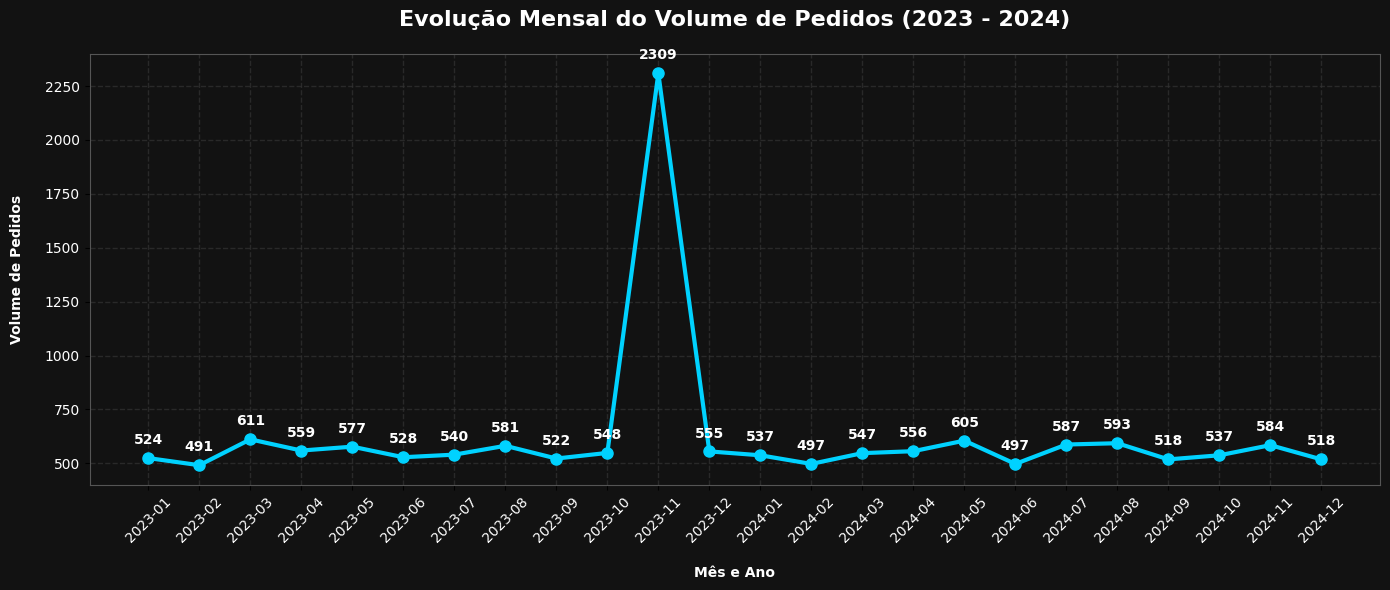


HIPÓTESE 1: ESTRATÉGIA DE DESCONTOS (Refutada)
Penetração de Cupons de Desconto (Volume %):


cupom_desconto,não,sim
ano_mes_str,,
2023-11,65.6%,34.4%
2024-11,68.0%,32.0%



HIPÓTESE 2: O FALSO PICO (CONTRATOS B2B ATÍPICOS)
Distribuição do Volume de Pedidos por Segmento (%):


segmento,B2B,B2C
ano_mes_str,,
2023-11,19.8%,80.2%
2024-11,22.4%,77.6%



HIPÓTESE 3: RUPTURA OPERACIONAL (TAXA DE CANCELAMENTO)
Status dos Pedidos - Sucesso vs Falha (%):


status,Cancelado,Devolvido,Em Trânsito,Entregue
ano_mes_str,,,,
2023-11,17.4%,7.2%,9.9%,65.5%
2024-11,16.1%,6.3%,10.1%,67.5%



HIPÓTESE 4: ERRO DE SISTEMA (DUPLICAÇÃO DE DADOS)
Total de Pedidos em Nov/23: 2309
Pedidos DUPLICADOS em Nov/23: 0

✅ Base limpa. Não há duplicações. O pico foi um fenômeno real de Marketing/Tráfego.


In [2]:
# 4) Analise a evolução mensal do volume de pedidos ao longo de 2023 e 2024. Há sazonalidade? Identifique picos e quedas e formule uma hipótese para cada padrão encontrado.

import pandas as pd
import matplotlib.pyplot as plt

df_pedidos = pd.read_csv('../data/pedidos_limpo.csv')
df_itens = pd.read_csv('../data/itens_pedido_limpo.csv')
df_clientes = pd.read_csv('../data/clientes_limpo.csv')

NOME_COLUNA_DATA = 'data_pedido' 
df_pedidos[NOME_COLUNA_DATA] = pd.to_datetime(df_pedidos[NOME_COLUNA_DATA], errors='coerce')

df_pedidos = df_pedidos.dropna(subset=[NOME_COLUNA_DATA])
df_pedidos_filtrado = df_pedidos[(df_pedidos[NOME_COLUNA_DATA].dt.year >= 2023) & (df_pedidos[NOME_COLUNA_DATA].dt.year <= 2024)].copy()
df_pedidos_filtrado['ano_mes'] = df_pedidos_filtrado[NOME_COLUNA_DATA].dt.to_period('M')
evolucao_mensal = df_pedidos_filtrado.groupby('ano_mes').size()

COR_FUNDO = '#121212'
fig = plt.figure(figsize=(14, 6), facecolor=COR_FUNDO)
ax = plt.axes()
ax.set_facecolor(COR_FUNDO)

x_labels = evolucao_mensal.index.astype(str)
plt.plot(x_labels, evolucao_mensal.values, color='#00D2FF', marker='o', linewidth=3, markersize=8)

plt.title('Evolução Mensal do Volume de Pedidos (2023 - 2024)', fontsize=16, fontweight='bold', color='white', pad=20)
plt.xlabel('Mês e Ano', color='white', fontweight='bold', labelpad=15)
plt.ylabel('Volume de Pedidos', color='white', fontweight='bold', labelpad=15)

plt.xticks(rotation=45, color='white')
plt.yticks(color='white')
ax.grid(color='#333333', linestyle='--', linewidth=1, alpha=0.7)

for spine in ax.spines.values():
    spine.set_color('#555555')

for i, valor in enumerate(evolucao_mensal.values):
    ax.annotate(f'{valor}', (x_labels[i], valor), textcoords="offset points", xytext=(0,10), ha='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================================
# PREPARAÇÃO PARA ANÁLISE DE HIPÓTESES (Apenas Nov/23 e Nov/24)
# ==========================================================
df_pedidos_filtrado['ano_mes_str'] = df_pedidos_filtrado[NOME_COLUNA_DATA].dt.strftime('%Y-%m')
df_novembro = df_pedidos_filtrado[df_pedidos_filtrado['ano_mes_str'].isin(['2023-11', '2024-11'])].copy()
mapeamento_status = {'em_transito': 'Em Trânsito', 'entregue': 'Entregue', 'cancelado': 'Cancelado', 'aguardando_pagamento': 'Aguardando Pagamento', 'devolvido': 'Devolvido'}
df_novembro['status'] = df_novembro['status'].map(mapeamento_status).fillna(df_novembro['status'].str.title())


# ==========================================================
# PARTE B: VALIDAÇÃO DA HIPÓTESE 1 (CUPONS E DESCONTOS) - Já Refutada por você
# ==========================================================
print("\n" + "="*70)
print("HIPÓTESE 1: ESTRATÉGIA DE DESCONTOS (Refutada)")
print("="*70)
uso_cupons = df_novembro.groupby('ano_mes_str')['cupom_desconto'].value_counts(normalize=True).unstack() * 100
print("Penetração de Cupons de Desconto (Volume %):")
display(uso_cupons.fillna(0).round(1).style.format("{:.1f}%"))


# ==========================================================
# PARTE C: VALIDAÇÃO DA HIPÓTESE 2 (O EFEITO B2B)
# ==========================================================
print("\n" + "="*70)
print("HIPÓTESE 2: O FALSO PICO (CONTRATOS B2B ATÍPICOS)")
print("="*70)
df_novembro_clientes = pd.merge(df_novembro, df_clientes, left_on='cliente_id', right_on='id', how="inner", validate="many_to_many")
distribuicao_segmento = df_novembro_clientes.groupby('ano_mes_str')['segmento'].value_counts(normalize=True).unstack() * 100
print("Distribuição do Volume de Pedidos por Segmento (%):")
display(distribuicao_segmento.fillna(0).round(1).style.format("{:.1f}%"))


# ==========================================================
# PARTE D: VALIDAÇÃO DA HIPÓTESE 3 (RUPTURA LOGÍSTICA / CANCELAMENTOS)
# ==========================================================
print("\n" + "="*70)
print("HIPÓTESE 3: RUPTURA OPERACIONAL (TAXA DE CANCELAMENTO)")
print("="*70)
distribuicao_status = df_novembro.groupby('ano_mes_str')['status'].value_counts(normalize=True).unstack() * 100
print("Status dos Pedidos - Sucesso vs Falha (%):")
display(distribuicao_status.fillna(0).round(1).style.format("{:.1f}%"))

# ==========================================================
# PARTE E: TESTE DE INTEGRIDADE DOS DADOS (DUPLICIDADE)
# ==========================================================
print("\n" + "="*70)
print("HIPÓTESE 4: ERRO DE SISTEMA (DUPLICAÇÃO DE DADOS)")
print("="*70)

# Isolando apenas Novembro de 2023
df_nov_23 = df_novembro[df_novembro['ano_mes_str'] == '2023-11']

# Contando quantos IDs de pedidos estão repetidos
duplicados = df_nov_23.duplicated(subset=['id']).sum()
total_pedidos = len(df_nov_23)

print(f"Total de Pedidos em Nov/23: {total_pedidos}")
print(f"Pedidos DUPLICADOS em Nov/23: {duplicados}")

if duplicados > 0:
    print(f"\n🚨 ALERTA: {duplicados} pedidos são clones! Isso inflou o gráfico.")
    print("A sazonalidade real é falsa. O pico foi um erro de banco de dados (Bug no sistema).")
else:
    print("\n✅ Base limpa. Não há duplicações. O pico foi um fenômeno real de Marketing/Tráfego.")